In [1]:
# Loading the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

In [2]:
# Importing the Dataset
import pandas as pd
df_2016 = pd.read_excel("mental-heath-in-tech-2016.xlsx")


In [3]:
df_2016.shape

(1433, 63)

## STEP 3. Data Cleaning and Preprocessing¶
Dropping Unnecessary Columns

Handling Missing Values for Categorical Columns

Handling Outliers and Missing Values in the Age Column

In [4]:
# Columns in our Dataset
df_2016.columns

Index(['Are you self-employed?',
       'How many employees does your company or organization have?',
       'Is your employer primarily a tech company/organization?',
       'Is your primary role within your company related to tech/IT?',
       'Does your employer provide mental health benefits as part of healthcare coverage?',
       'Do you know the options for mental health care available under your employer-provided coverage?',
       'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
       'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
       'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
       'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
       'Do you think that dis

In [5]:
# Dictionary mapping original long column names to shorter names
short_names = {
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'company_size',
    'Is your employer primarily a tech company/organization?': 'is_tech_company',
    'Is your primary role within your company related to tech/IT?': 'role_tech',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'provides_mh_benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'know_mh_options',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'employer_formal_mh_discussion',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'employer_resources',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity_protected',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'comfort_request_leave',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mh_negative_consequences',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'phys_health_negative_consequences',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'comfortable_discuss_coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'comfortable_discuss_supervisors',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'employer_takes_mh_seriously',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'observed_neg_consequences',
    "Do you have medical coverage (private insurance or state-provided) which includes treatment of Â\xa0mental health issues?":'coverage_includes_mh',
    'Do you know local or online resources to seek help for a mental health disorder?': 'know_local_online_resources',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?': 'reveal_to_clients',
    'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?': 'negative_impacts_clients',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?': 'reveal_to_coworkers',
    'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?': 'negative_impacts_coworkers',
    'Do you believe your productivity is ever affected by a mental health issue?': 'productivity_affected',
    'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?': 'percent_time_affected',
    'Do you have previous employers?': 'previous_employers',
    'Have your previous employers provided mental health benefits?': 'previous_mh_benefits',
    'Were you aware of the options for mental health care provided by your previous employers?': 'aware_previous_mh_options',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': 'previous_formal_mh_discussion',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': 'previous_resources',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?': 'previous_anonymity_protected',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': 'previous_mh_negative_consequences',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': 'previous_phys_health_neg_consequences',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': 'previous_comfort_discuss_coworkers',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': 'previous_comfort_discuss_supervisors',
    'Did you feel that your previous employers took mental health as seriously as physical health?': 'previous_mh_taken_seriously',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': 'previous_observed_neg_consequences',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'willing_phys_health_discuss_interview',
    'Why or why not?': 'phys_health_why_not',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'willing_mh_discuss_interview',
    'Why or why not?.1': 'mh_why_not',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': 'mh_hurt_career',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': 'mh_viewed_negatively',
    'How willing would you be to share with friends and family that you have a mental illness?': 'willing_share_friendsfamily',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?': 'unsupportive_response',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?': 'less_likely_reveal',
    'Do you have a family history of mental illness?': 'family_history_mh',
    'Have you had a mental health disorder in the past?': 'past_mh_disorder',
    'Do you currently have a mental health disorder?': 'current_mh_disorder',
    'If yes, what condition(s) have you been diagnosed with?': 'diagnosed_conditions',
    'If maybe, what condition(s) do you believe you have?': 'suspected_conditions',
    'Have you been diagnosed with a mental health condition by a medical professional?': 'diagnosed_by_professional',
    'If so, what condition(s) were you diagnosed with?': 'diagnosed_conditions_professional',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment_sought',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'interferes_work_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'interferes_work_not_treated',
    'What is your age?': 'age',
    'What is your gender?': 'gender',
    'What country do you live in?': 'country_live',
    'What US state or territory do you live in?': 'state_live',
    'What country do you work in?': 'country_work',
    'What US state or territory do you work in?': 'state_work',
    'Which of the following best describes your work position?': 'work_position',
    'Do you work remotely?': 'work_remotely'
}

# Rename the columns in the dataframe
df_2016.rename(columns=short_names, inplace=True)

print(df_2016.columns)


Index(['self_employed', 'company_size', 'is_tech_company', 'role_tech',
       'provides_mh_benefits', 'know_mh_options',
       'employer_formal_mh_discussion', 'employer_resources',
       'anonymity_protected', 'comfort_request_leave',
       'mh_negative_consequences', 'phys_health_negative_consequences',
       'comfortable_discuss_coworkers', 'comfortable_discuss_supervisors',
       'employer_takes_mh_seriously', 'observed_neg_consequences',
       'coverage_includes_mh', 'know_local_online_resources',
       'reveal_to_clients', 'negative_impacts_clients', 'reveal_to_coworkers',
       'negative_impacts_coworkers', 'productivity_affected',
       'percent_time_affected', 'previous_employers', 'previous_mh_benefits',
       'aware_previous_mh_options', 'previous_formal_mh_discussion',
       'previous_resources', 'previous_anonymity_protected',
       'previous_mh_negative_consequences',
       'previous_phys_health_neg_consequences',
       'previous_comfort_discuss_coworkers',

In [6]:
# Listing all the columns in our dataset that contain missing values together with the number of missing values
missing = df_2016.isnull().sum()
missing[missing > 0]

company_size                              287
is_tech_company                           287
role_tech                                1170
provides_mh_benefits                      287
know_mh_options                           420
employer_formal_mh_discussion             287
employer_resources                        287
anonymity_protected                       287
comfort_request_leave                     287
mh_negative_consequences                  287
phys_health_negative_consequences         287
comfortable_discuss_coworkers             287
comfortable_discuss_supervisors           287
employer_takes_mh_seriously               287
observed_neg_consequences                 287
coverage_includes_mh                     1146
know_local_online_resources              1146
reveal_to_clients                        1146
negative_impacts_clients                 1289
reveal_to_coworkers                      1146
negative_impacts_coworkers               1146
productivity_affected             

In [7]:
# Categorizing the gender group into three respective genders.
def categorize_gender(gender):
    if pd.isna(gender):
        return 'Other'
    gender_lower = gender.lower()
    if 'female' in gender_lower or 'woman' in gender_lower or gender_lower in ['f', 'fem', 'cis female', 'cis-woman', 'female-bodied; no feelings about gender', 'female assigned at birth ', 'female ', ' i identify as female.', 'female or multi-gender femme','Woman','Female (props for making this a freeform field, though)']:
        return 'Female'
    elif 'male' in gender_lower or 'man' in gender_lower or gender_lower in ['m', 'mail', 'Male/genderqueer', 'cis male','M|', 'cisdude', 'Male (cis)', 'male.', 'sex is male', 'male (cis)', 'male (trans, ftm)', 'male/genderqueer', 'malr', 'nb masculine','dude']:
        return 'Male'
    else:
        return 'Other'

df_2016['Gender_Grouped'] = df_2016['gender'].apply(categorize_gender)

display(df_2016['Gender_Grouped'].value_counts()) # Display value counts from df_2016

Gender_Grouped
Male      1061
Female     343
Other       29
Name: count, dtype: int64

In [8]:
df_2016.info()

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 64 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   self_employed                          1433 non-null   int64  
 1   company_size                           1146 non-null   object 
 2   is_tech_company                        1146 non-null   float64
 3   role_tech                              263 non-null    float64
 4   provides_mh_benefits                   1146 non-null   str    
 5   know_mh_options                        1013 non-null   str    
 6   employer_formal_mh_discussion          1146 non-null   str    
 7   employer_resources                     1146 non-null   str    
 8   anonymity_protected                    1146 non-null   str    
 9   comfort_request_leave                  1146 non-null   str    
 10  mh_negative_consequences               1146 non-null   str    
 11  phys_health_neg

In [9]:
# Select the relevant columns from df_2016 and assign to the new df
relevant_cols = [
    'comfort_request_leave',
    'interferes_work_treated',
    'interferes_work_not_treated',
    'provides_mh_benefits',
    'know_mh_options',
    'employer_formal_mh_discussion',
    'employer_resources',
    'anonymity_protected',
    'self_employed',
    'age',
    'unsupportive_response',
    'work_position',
    'work_remotely',
    'treatment_sought',
    'family_history_mh',
    'current_mh_disorder',
    'past_mh_disorder',
    'diagnosed_by_professional',
    'Gender_Grouped'
]
df = df_2016[relevant_cols].copy()

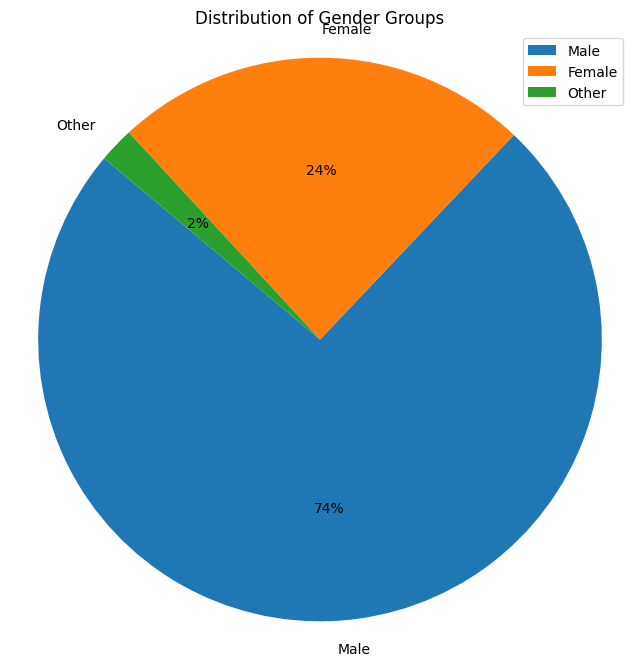

In [10]:
# Calculate the percentage of each gender group
gender_percentages = df['Gender_Grouped'].value_counts(normalize=True) * 100

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(gender_percentages, labels=gender_percentages.index, autopct='%1.0f%%', startangle=140)
plt.title('Distribution of Gender Groups')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.legend()
plt.show()

In [11]:
# Explicitly remove age outliers: 3 and 323
df = df[~df['age'].isin([3, 323])]

# Filter to only include rows where the value in the column "age" is between 18 and 65, inclusive.
age_range = df[(df["age"] >= 18) & (df["age"] <= 65)]
display(age_range)

,comfort_request_leave,interferes_work_treated,interferes_work_not_treated,provides_mh_benefits,know_mh_options,employer_formal_mh_discussion,employer_resources,anonymity_protected,self_employed,age,unsupportive_response,work_position,work_remotely,treatment_sought,family_history_mh,current_mh_disorder,past_mh_disorder,diagnosed_by_professional,Gender_Grouped
0,Very easy,Not applicable to me,Not applicable to me,Not eligible for coverage / N/A,NaN,No,No,I don't know,0,39,No,Back-end Developer,Sometimes,0,No,No,Yes,Yes,Male
1,Somewhat easy,Rarely,Sometimes,No,Yes,Yes,Yes,Yes,0,29,No,Back-end Developer|Front-end Developer,Never,1,Yes,Yes,Yes,Yes,Male
2,Neither easy nor difficult,Not applicable to me,Not applicable to me,No,NaN,No,No,I don't know,0,38,Maybe/Not sure,Back-end Developer,Always,1,No,No,Maybe,No,Male
3,NaN,Sometimes,Sometimes,NaN,NaN,NaN,NaN,NaN,1,43,No,Supervisor/Team Lead,Sometimes,1,No,Yes,Yes,Yes,Male
4,Neither easy nor difficult,Sometimes,Sometimes,Yes,Yes,No,No,No,0,43,"Yes, I experienced",Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes,1,Yes,Yes,Yes,Yes,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,NaN,Not applicable to me,Not applicable to me,NaN,NaN,NaN,NaN,NaN,1,34,Maybe/Not sure,Other,Sometimes,1,Yes,No,No,No,Female
1429,NaN,Sometimes,Often,NaN,NaN,NaN,NaN,NaN,1,56,Maybe/Not sure,Support,Sometimes,0,Yes,No,No,Yes,Male
1430,Somewhat difficult,Rarely,Sometimes,Yes,Yes,Yes,Yes,I don't know,0,52,"Yes, I observed",Back-end Developer,Sometimes,1,Yes,Maybe,Yes,Yes,Male
1431,Somewhat difficult,Sometimes,Often,I don't know,I am not sure,No,Yes,I don't know,0,30,"Yes, I experienced",DevOps/SysAdmin,Sometimes,0,Yes,Yes,Maybe,Yes,Female


In [12]:
# Check for missing values in the selected relevant columns
print("Missing values in relevant columns before handling:")
display(df[relevant_cols].isnull().sum())

Missing values in relevant columns before handling:


comfort_request_leave            287
interferes_work_treated            0
interferes_work_not_treated        0
provides_mh_benefits             287
know_mh_options                  420
employer_formal_mh_discussion    287
employer_resources               287
anonymity_protected              287
self_employed                      0
age                                0
unsupportive_response             89
work_position                      0
work_remotely                      0
treatment_sought                   0
family_history_mh                  0
current_mh_disorder                0
past_mh_disorder                   0
diagnosed_by_professional          0
Gender_Grouped                     0
dtype: int64

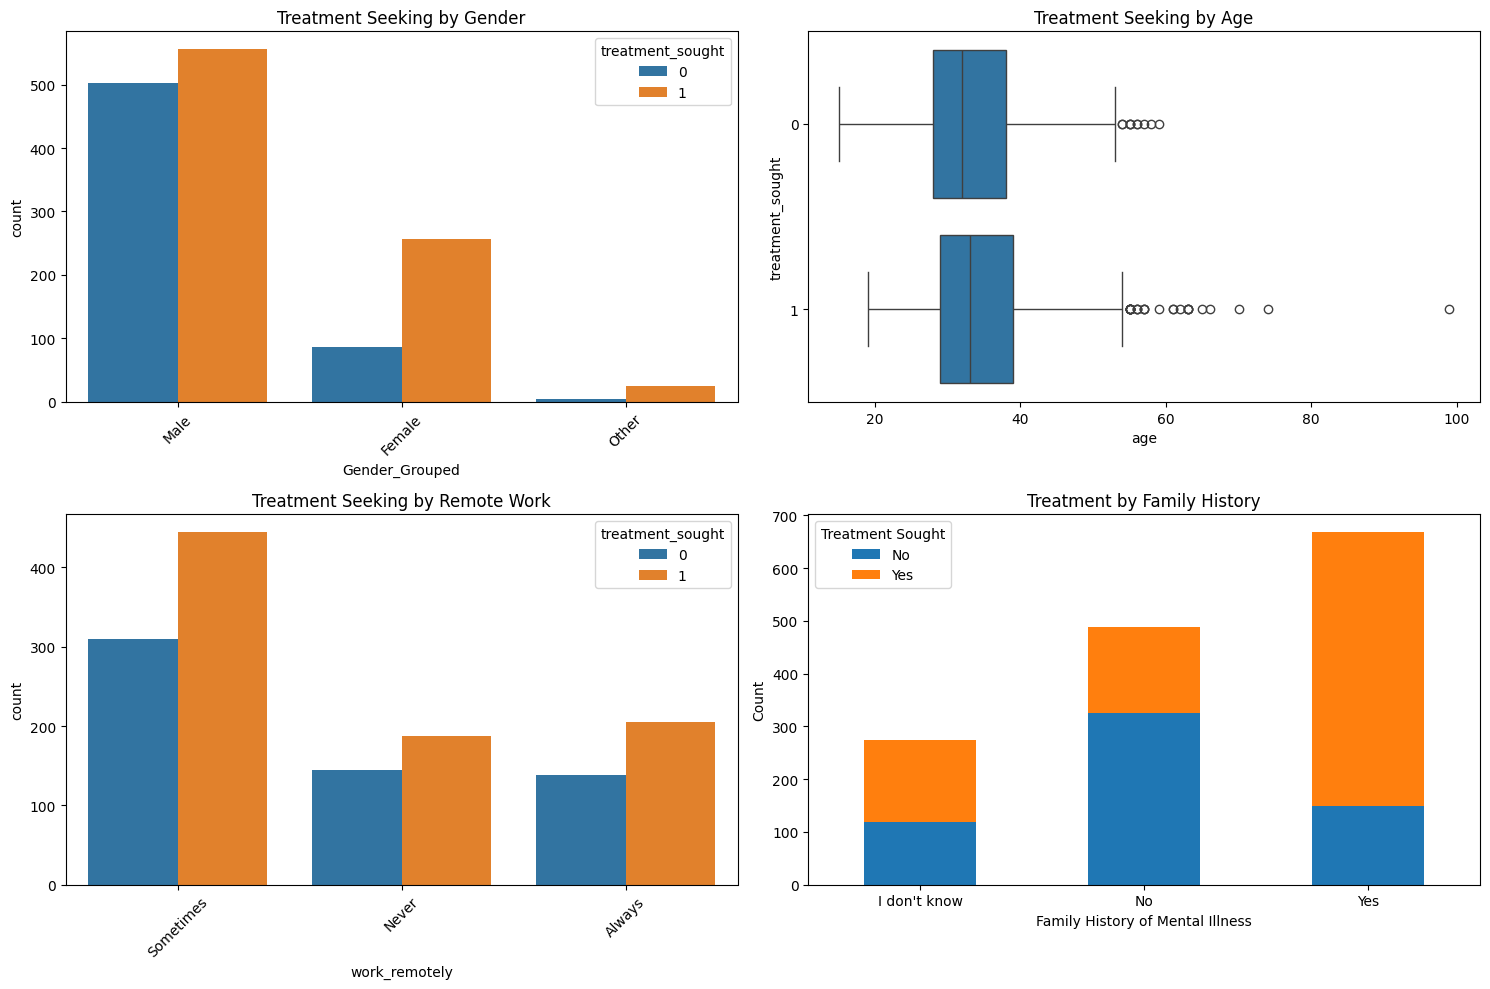

In [13]:
# A visual of the relationships between some columns in our datasets
# Assuming a 2x2 grid for four plots
plt.figure(figsize=(15, 10)) # Increased figure size for better readability

# Plot 1: Treatment Seeking by Gender (using df)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Gender_Grouped', hue='treatment_sought')
plt.title('Treatment Seeking by Gender')
plt.xticks(rotation=45)

# Plot 2: Treatment Seeking by Age (using df)
plt.subplot(2, 2, 2)
sns.boxplot(data=df, y='treatment_sought', x='age', orient = 'h')
plt.title('Treatment Seeking by Age')

# Plot 3: Treatment Seeking by Remote Work (using df)
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='work_remotely', hue='treatment_sought')
plt.title('Treatment Seeking by Remote Work')
plt.xticks(rotation=45)

# Plot 4: Treatment by Family History (using counts from original df)
# We need the 'family_history_counts_original' variable from the previous cell
# Ensure cell H3hmkPJI8cht is run before this cell to have 'family_history_counts_original' defined
plt.subplot(2, 2, 4)
# Calculate family_history_counts_original using the current dataframe df
family_history_counts_original = df.groupby('family_history_mh')['treatment_sought'].value_counts().unstack().fillna(0)
family_history_counts_original.plot(kind='bar', stacked=True, ax=plt.gca()) # Use ax=plt.gca() to plot on the subplot
plt.title("Treatment by Family History")
plt.xlabel("Family History of Mental Illness")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title='Treatment Sought', labels=['No', 'Yes'])
plt.savefig("EDA.png")



plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show() # Display the figure with all subplots

In [14]:
df.describe()

,self_employed,age,treatment_sought
count,1431.000000,1431.000000,1431.000000
mean,0.200559,34.106219,0.585604
std,0.400559,8.285882,0.492790
min,0.000000,15.000000,0.000000
25%,0.000000,28.000000,0.000000
50%,0.000000,33.000000,1.000000
75%,0.000000,39.000000,1.000000
max,1.000000,99.000000,1.000000


## Filling Missing Values with the Mode For Categorical Columns

In [15]:

# Get all object columns (categorical columns)
object_cols = df.select_dtypes(include='object').columns

# Replace empty strings and strings with only whitespace with np.nan
# This makes sure fillna can catch them
for col in object_cols:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

# Fill all NaN values (including those converted from blank spaces) with 'NA'
df = df.fillna('NAN')

print("Missing values after filling with 'NAN':")
display(df.isnull().sum())

Missing values after filling with 'NAN':


comfort_request_leave            0
interferes_work_treated          0
interferes_work_not_treated      0
provides_mh_benefits             0
know_mh_options                  0
employer_formal_mh_discussion    0
employer_resources               0
anonymity_protected              0
self_employed                    0
age                              0
unsupportive_response            0
work_position                    0
work_remotely                    0
treatment_sought                 0
family_history_mh                0
current_mh_disorder              0
past_mh_disorder                 0
diagnosed_by_professional        0
Gender_Grouped                   0
dtype: int64

## Filling NAN's with the Mode


In [16]:
# Target columns provided by the user
mode_cols_to_process = [
    'comfort_request_leave',
    'provides_mh_benefits',
    'know_mh_options',
    'employer_formal_mh_discussion',
    'employer_resources',
    'anonymity_protected',
    'unsupportive_response',
    'interferes_work_treated',
    'diagnosed_by_professional',
    'work_remotely',
    'treatment_sought',
    'family_history_mh',
    'past_mh_disorder',
    'current_mh_disorder',
]

# Iterate through each column and replace 'NAN' with its mode
for col in mode_cols_to_process:
    if col in df.columns and df[col].dtype == 'object': # Only process object type columns
        # Calculate mode, excluding 'NAN' from consideration if it exists as a string value
        # .mode()[0] handles cases where multiple modes exist by picking the first
        mode_val = df[df[col] != 'NAN'][col].mode()[0] if not df[df[col] != 'NAN'][col].mode().empty else 'Unknown'
        df[col] = df[col].replace('NAN', mode_val)

# Verify that 'NAN' string is no longer present in these columns
print("Remaining 'NAN' string values in specified columns after filling with mode:")
for col in mode_cols_to_process:
    if col in df.columns and df[col].dtype == 'object':
        if 'NAN' in df[col].unique():
            print(f"  - {col}: 'NAN' still present")
        else:
            print(f"  - {col}: 'NAN' successfully removed")
    elif col in df.columns and df[col].dtype != 'object':
        print(f"  - {col}: Skipped (not object type)")
    else:
        print(f"  - {col}: Column not found")


Remaining 'NAN' string values in specified columns after filling with mode:
  - comfort_request_leave: Skipped (not object type)
  - provides_mh_benefits: Skipped (not object type)
  - know_mh_options: Skipped (not object type)
  - employer_formal_mh_discussion: Skipped (not object type)
  - employer_resources: Skipped (not object type)
  - anonymity_protected: Skipped (not object type)
  - unsupportive_response: Skipped (not object type)
  - interferes_work_treated: Skipped (not object type)
  - diagnosed_by_professional: Skipped (not object type)
  - work_remotely: Skipped (not object type)
  - treatment_sought: Skipped (not object type)
  - family_history_mh: Skipped (not object type)
  - past_mh_disorder: Skipped (not object type)
  - current_mh_disorder: Skipped (not object type)


In [17]:
# List of columns for which to get unique values
columns_for_unique_values = [
    'comfort_request_leave',
    'provides_mh_benefits',
    'know_mh_options',
    'employer_formal_mh_discussion',
    'employer_resources',
    'anonymity_protected',
    'unsupportive_response',
    'interferes_work_treated',
    'diagnosed_by_professional',
    'work_remotely',
    'treatment_sought',
    'family_history_mh',
    'past_mh_disorder',
    'current_mh_disorder',
]

# Create an empty list to store dictionaries of unique values
unique_values_list = []

# Iterate through each column and get its unique values
for col in columns_for_unique_values:
    if col in df.columns:
        unique_vals = df[col].unique().tolist()
        unique_values_list.append({'Column': col, 'Unique Values': unique_vals})
    else:
        unique_values_list.append({'Column': col, 'Unique Values': 'Column not found'})

# Create a DataFrame from the list of dictionaries
unique_values_df = pd.DataFrame(unique_values_list)

# Display the DataFrame
unique_values_df

,Column,Unique Values
0,comfort_request_leave,"[Very easy, Somewhat easy, Neither easy nor di..."
1,provides_mh_benefits,"[Not eligible for coverage / N/A, No, NAN, Yes..."
2,know_mh_options,"[NAN, Yes, I am not sure, No]"
3,employer_formal_mh_discussion,"[No, Yes, NAN, I don't know]"
4,employer_resources,"[No, Yes, NAN, I don't know]"
5,anonymity_protected,"[I don't know, Yes, NAN, No]"
6,unsupportive_response,"[No, Maybe/Not sure, Yes, I experienced, Yes, ..."
7,interferes_work_treated,"[Not applicable to me, Rarely, Sometimes, Neve..."
8,diagnosed_by_professional,"[Yes, No]"
9,work_remotely,"[Sometimes, Never, Always]"


In [18]:
df.work_position.unique()

<StringArray>
[                                                                                                              'Back-end Developer',
                                                                                           'Back-end Developer|Front-end Developer',
                                                                                                             'Supervisor/Team Lead',
 'Executive Leadership|Supervisor/Team Lead|Dev Evangelist/Advocate|DevOps/SysAdmin|Support|Back-end Developer|Front-end Developer',
                                                          'DevOps/SysAdmin|Support|Back-end Developer|Front-end Developer|Designer',
                                                                                       'Dev Evangelist/Advocate|Back-end Developer',
                                                                                       'Support|Back-end Developer|One-person shop',
                                                       

# Using Label Encoding for categorical columns  and Standard Scaler for Numeric columns

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Identify categorical columns excluding the target variable
categorical_cols = df.select_dtypes(include='object').columns
# No need to remove 'treatment_sought' here as we will drop it later for X


# Identify numerical columns (only 'age' needs scaling based on the request and data)
numerical_cols = ['age']

# Columns for Label Encoding (excluding 'age' which is numerical and columns for one-hot encoding and the target)
label_encode_cols = [col for col in categorical_cols if col not in ['treatment_sought']]

# Apply One-Hot Encoding to all categorical columns except 'treatment_sought'
# We will drop 'treatment_sought' before creating X and y
df_encoded = pd.get_dummies(df, columns=[col for col in categorical_cols if col != 'treatment_sought'], dummy_na=False)

# Convert boolean columns created by get_dummies to integers (0s and 1s)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# Apply StandardScaler to 'age'
scaler = StandardScaler()
df_encoded['age'] = scaler.fit_transform(df_encoded[['age']])

# Re-create X and y from the newly generated df_encoded
X = df_encoded.drop(columns=['treatment_sought'])
y = df_encoded['treatment_sought']

display(df_encoded.head())


,self_employed,age,treatment_sought,comfort_request_leave_I don't know,comfort_request_leave_NAN,comfort_request_leave_Neither easy nor difficult,comfort_request_leave_Somewhat difficult,comfort_request_leave_Somewhat easy,comfort_request_leave_Very difficult,comfort_request_leave_Very easy,...,current_mh_disorder_No,current_mh_disorder_Yes,past_mh_disorder_Maybe,past_mh_disorder_No,past_mh_disorder_Yes,diagnosed_by_professional_No,diagnosed_by_professional_Yes,Gender_Grouped_Female,Gender_Grouped_Male,Gender_Grouped_Other
0,0,0.590823,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,1,0,1,0
1,0,-0.616471,1,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,1,0
2,0,0.470094,1,0,0,1,0,0,0,0,...,1,0,1,0,0,1,0,0,1,0
3,1,1.073741,1,0,1,0,0,0,0,0,...,0,1,0,0,1,0,1,0,1,0
4,0,1.073741,1,0,0,1,0,0,0,0,...,0,1,0,0,1,0,1,1,0,0


##Modeling

Extracting features and labels as numpy matrices

In [20]:
# Split the data into features (X) and target variable (y)
X = df_encoded.drop(columns=['treatment_sought'])
y = df_encoded['treatment_sought']
labels_df,features_df=X,y

# test data amount (in terms of proportion)
TEST_PROP = 0.2
# Random number seed; important for experiment reproducibility
RANDOM_SEED = 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_PROP, random_state=RANDOM_SEED)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1144, 326), (1144,), (287, 326), (287,))

In [21]:
# After your train_test_split
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Original train: {np.bincount(y_train)}")
print(f"Resampled train: {np.bincount(y_train_res)}")  # Should balance classes

Original train: [478 666]
Resampled train: [666 666]


## Baseline Model

In [22]:
# Lets normalize the features.
random_state=42
# Scale ONLY for non-trees (LR/SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# FIXED: Models (defaults, no CV in fit)
baseline_models_new = {
    "Logistic Regression": LogisticRegression(max_iter=1000,solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(),
}

baseline_results_new = []

for name, model in baseline_models_new.items():
    print(f"Evaluating {name}...")
    if name in ["KNN", "Logistic Regression", "SVM", "Neural Network"]:
        X_train_fit = X_train_scaled
        X_test_fit = X_test_scaled
    else:
        X_train_fit = X_train
        X_test_fit = X_test

    if len(X_train_fit) != len(y_train):
        print(f"Warning: Shape mismatch for {name}")
        continue
    model.fit(X_train_fit, y_train)

    # Preds
    train_preds = model.predict(X_train_fit)
    test_preds = model.predict(X_test_fit)

    # FIXED: Metrics (no CV for initial baseline)
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    precision_macro = precision_score(y_test, test_preds, average='macro')
    recall_macro = recall_score(y_test, test_preds, average='macro')
    f1_macro = f1_score(y_test, test_preds, average='macro')
    overfit_gap = train_acc - test_acc

    baseline_results_new.append({
        "Model": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Precision (Macro)": round(precision_macro, 4),
        "Recall (Macro)": round(recall_macro, 4),
        "F1 (Macro)": round(f1_macro, 4),
        "Overfit Gap": round(overfit_gap, 4)
    })
baseline_comparison_df = pd.DataFrame(baseline_results_new)
display(baseline_comparison_df)

# Save
baseline_comparison_df.to_csv('initial_raw_baseline_results.csv', index=False)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...


,Model,Train Acc,Test Acc,Precision (Macro),Recall (Macro),F1 (Macro),Overfit Gap
0,Logistic Regression,0.9117,0.8362,0.8287,0.8346,0.8311,0.0755
1,Random Forest,1.0000,0.8571,0.8523,0.8491,0.8506,0.1429
2,Gradient Boosting,0.9213,0.8676,0.8616,0.8636,0.8625,0.0537


## Graph of the Baseline Model

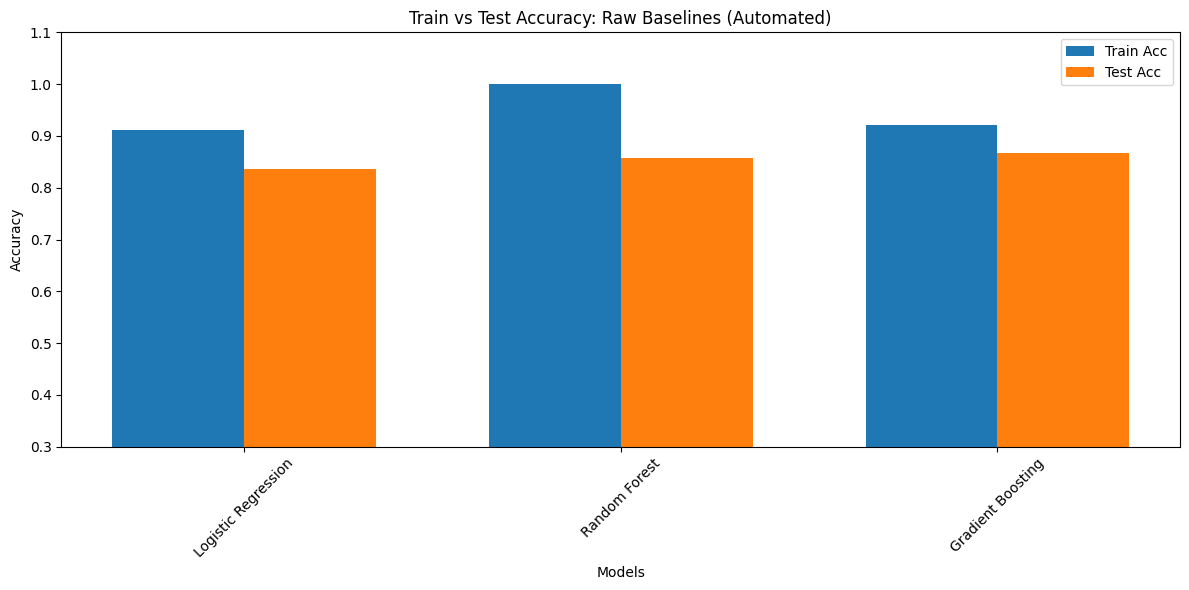

In [23]:
# Graph (automated from table)
models = baseline_comparison_df['Model'].tolist()
train_accs = baseline_comparison_df['Train Acc'].tolist()
test_accs = baseline_comparison_df['Test Acc'].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, train_accs, width, label='Train Acc')
ax.bar(x + width/2, test_accs, width, label='Test Acc')
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy: Raw Baselines (Automated)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()
ax.set_ylim(0.3, 1.1)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning on Baseline Model



**Reasoning**:
Initialize a `StandardScaler` object as requested, which will be used later for scaling features in models that require it.



In [24]:
# Expanded grids (wider ranges + extras)
models_tuned = {
    "Logistic Regression": (
        LogisticRegression(random_state=RANDOM_SEED, solver='liblinear', class_weight='balanced', max_iter=1000),
        {'C': uniform(0.01, 10), 'penalty': ['l1', 'l2']}  # Wider C for flexibility
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced'),
        {
            'n_estimators': randint(50, 500),  # More trees
            'max_depth': randint(3, 20),       # Deeper for interactions
            'min_samples_leaf': randint(1, 10),
            'min_samples_split': randint(2, 10),  # New: Better splits
            'ccp_alpha': uniform(0.0001, 0.1)    # Wider pruning
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_SEED),
        {
            'n_estimators': randint(50, 300),    # More stages
            'max_depth': randint(2, 10),         # Shallower base, wider search
            'learning_rate': uniform(0.01, 0.3), # Slower/faster steps
            'subsample': uniform(0.7, 0.3)       # New: Bagging fraction for variance
        }
    ),
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
tuned_results = []

for name, (model, param_grid) in models_tuned.items():
    print(f"Tuning {name}...")

    # Scaled for Logistic, original data for trees
    if name == "Logistic Regression":
        X_train_fit = X_train_scaled
        X_test_fit = X_test_scaled
    else:
        # Use original X_train and X_test for tree-based models
        X_train_fit = X_train
        X_test_fit = X_test

    # Increased search (50 iters, F1 focus)
    search = RandomizedSearchCV(
        model, param_grid, n_iter=50, cv=cv, scoring='f1_macro',
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )
    search.fit(X_train_fit, y_train)
    best_model = search.best_estimator_

    # Metrics
    train_preds = best_model.predict(X_train_fit)
    test_preds = best_model.predict(X_test_fit)
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    precision_macro = precision_score(y_test, test_preds, average='macro')
    recall_macro = recall_score(y_test, test_preds, average='macro')
    f1_macro = f1_score(y_test, test_preds, average='macro')
    cv_score = search.best_score_
    overfit_gap = train_acc - test_acc

    tuned_results.append({
        "Model": name,
        "Train Acc": round(train_acc, 4),
        "Test Acc": round(test_acc, 4),
        "Precision": round(precision_macro, 4),
        "Recall": round(recall_macro, 4),
        "F1": round(f1_macro, 4),
        "CV Score": round(cv_score, 4),
        "Overfit Gap": round(overfit_gap, 4)
    })

tuned_df = pd.DataFrame(tuned_results)
display(tuned_df)
tuned_df.to_csv('tuned_improved_results.csv', index=False)

Tuning Logistic Regression...
Tuning Random Forest...
Tuning Gradient Boosting...


,Model,Train Acc,Test Acc,Precision,Recall,F1,CV Score,Overfit Gap
0,Logistic Regression,0.9117,0.8467,0.8395,0.8447,0.8417,0.8607,0.065
1,Random Forest,0.8706,0.8676,0.8609,0.8665,0.8633,0.8695,0.003
2,Gradient Boosting,0.8916,0.8746,0.8694,0.8694,0.8694,0.8708,0.017


**Deep Learning Model** : **Feed Forward Neural Network**



## FNN


In [25]:
# importing PCA module
from sklearn.decomposition import PCA

In [26]:
# fitting the PCA model
pca = PCA(n_components=10)
pca.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [27]:
# perform copression
X_compressed = pca.transform(X)
X.shape, X_compressed.shape

((1431, 326), (1431, 10))

In [28]:
# plotting the per component variances
fig = px.bar(x=np.arange(X_compressed.shape[1]), y=pca.explained_variance_ratio_)
fig.show()
print(np.sum(pca.explained_variance_ratio_))

0.12394199111388916


In [29]:
# Multi-Layer Perceptron
from sklearn.neural_network import MLPClassifier

In [30]:
# models dictionary
params = {
    'hidden_layer_sizes': (128, 64, 32),
    'activation': 'tanh',
    'solver': 'adam',
    'alpha': 1e-5,
    'learning_rate_init':0.001,
    'max_iter':2000,
    'early_stopping': True,
    'validation_fraction': 0.1,
    'n_iter_no_change': 10,
    'random_state': 42
}

model_repo = {
    'lr': LogisticRegression(),
    'rf': RandomForestClassifier(),
    'gb': GradientBoostingClassifier(),
    'nn': MLPClassifier(
        hidden_layer_sizes=(1024,),
        alpha=1e-8,
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=False,
        activation='tanh',
        random_state=42,
        solver='adam',
        validation_fraction=0.01,
        n_iter_no_change=20)
}

In [33]:
class myClassificationModel:
    def __init__(self, model):
        self.model = model
    
    def train(self, X, y):
        self.model.fit(X, y)
    
    def evaluate(self, X, y):
        return self.model.score(X, y)
    
    def cv_error(self, X, y):
        from sklearn.model_selection import cross_val_score
        return cross_val_score(self.model, X, y, cv=5)

In [34]:
# Data splits
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_train, X_test = X_train_pca, X_test_pca

In [35]:
my_model = myClassificationModel(model_repo['nn'])
my_model.train(X_train, y_train)
# Train, test accuracy
training_accuracy, test_accuracy = my_model.evaluate(X_train, y_train), my_model.evaluate(X_test, y_test)
training_accuracy, test_accuracy

(0.9982517482517482, 0.5052264808362369)

In [36]:
# Cross validation
cv_scores = my_model.cv_error(X_compressed, y)
print('cross validation scores:', cv_scores)
print('cross validation score (mean):', np.mean(cv_scores))
print('cross validation score (std):', np.std(cv_scores))

cross validation scores: [0.87456446 0.87412587 0.86013986 0.82867133 0.87762238]
cross validation score (mean): 0.8630247800979509
cross validation score (std): 0.01820972674600729


In [37]:
# Calculate metrics for the last run of my_model
mlp_training_accuracy = training_accuracy # From previous execution
mlp_test_accuracy = test_accuracy # From previous execution
mlp_cv_mean_score = np.mean(cv_scores) # From previous execution
mlp_overfit_gap = mlp_training_accuracy - mlp_test_accuracy

# Create a DataFrame for the MLPClassifier results
mlp_summary_df = pd.DataFrame({
    "Model": ["FEED FORWARD NEURAL NETWORK"],
    "Train Acc": [round(mlp_training_accuracy, 4)],
    "Test Acc": [round(mlp_test_accuracy, 4)],
    "CV Score": [round(mlp_cv_mean_score, 4)],
    "Overfit Gap": [round(mlp_overfit_gap, 4)]
})

display(mlp_summary_df)

,Model,Train Acc,Test Acc,CV Score,Overfit Gap
0,FEED FORWARD NEURAL NETWORK,0.9983,0.5052,0.863,0.493
